# F1 race prediction with fastf1

Can we predict the finishing order of a Formula 1 race **before it happens**, using only information available before the lights go out?

This notebook builds a complete machine-learning pipeline:

1. **Collect** - qualifying and race results for every completed round of the season, plus practice-session lap analysis and sprint-weekend results, pulled from the official F1 timing data with the `fastf1` library.
2. **Explore** - how much does the starting grid actually determine the result?
3. **Engineer features** - grid position, qualifying pace vs pole, practice race pace, sprint-weekend results, driver and team form, championship points - all strictly known before the race starts.
4. **Model** - a histogram gradient-boosting regressor that predicts *places gained/lost relative to grid*, then ranks the field.
5. **Backtest** - a rolling simulation of the season: train only on past races, predict the next one, and compare against a "grid = result" baseline.
6. **Predict** - produce a full predicted finishing order (and podium) for the target race.

Requirements: `pip install fastf1 pandas numpy scikit-learn matplotlib`

A command-line version of the same pipeline lives in `predict_race.py`.

## 1. Setup

- `fastf1` stores downloaded timing data in a local `cache/` folder, so repeated runs are fast and don't re-hit the F1 API.
- Collected race data is persisted to `data/season_<year>.csv` and refreshed incrementally: after each new race you simply re-run the notebook and only the missing rounds are downloaded.
- `SEASON` controls which championship is analysed (the 2026 season is in progress, so that is the default).
- The fastf1 log level is raised so download chatter doesn't drown the notebook output.

In [1]:
import warnings
from datetime import datetime, timedelta, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import fastf1
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")

BASE_DIR = Path.cwd()
CACHE_DIR = BASE_DIR / "cache"
DATA_DIR = BASE_DIR / "data"
CACHE_DIR.mkdir(exist_ok=True)
DATA_DIR.mkdir(exist_ok=True)

fastf1.Cache.enable_cache(str(CACHE_DIR))
fastf1.logger.set_log_level("WARNING")

SEASON = 2026
MIN_TRAIN_ROUNDS = 5
STINT_WINDOW = 5
STINT_MIN_LAPS = 3
COMPLETION_BUFFER = timedelta(hours=3)

PRACTICE_COLS = ["fp_race_pace_delta", "fp_best_delta", "fp_laps"]
SPRINT_COLS = ["sprint_quali_pos", "sprint_finish", "sprint_gain"]

FEATURES = [
    "grid",
    "quali_delta",
    "team_quali_delta",
    "fp_race_pace_delta",
    "fp_best_delta",
    "fp_laps",
    "sprint_quali_pos",
    "sprint_finish",
    "sprint_gain",
    "driver_form_3",
    "driver_form_season",
    "driver_last_finish",
    "team_form_3",
    "team_form_season",
    "driver_points_before",
    "team_points_before",
    "team_id",
]

RAW_COLUMNS = [
    "round",
    "event",
    "driver_number",
    "driver",
    "team",
    "grid",
    "quali_time",
    "finish",
    "points",
    "status",
] + PRACTICE_COLS + SPRINT_COLS

plt.rcParams.update({
    "figure.figsize": (11, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
    "axes.titlesize": 12,
})

print("fastf1", fastf1.__version__, "| season", SEASON)

fastf1 3.8.3 | season 2026


## 2. Collecting race data

For every **completed round** of the season two sessions are loaded (laps/telemetry are skipped, which keeps loading fast):

- **Qualifying** -> each driver's best lap time across Q1-Q3, expressed as `quali_delta`, the gap to pole in seconds. This measures raw one-lap car pace.
- **Race** -> starting `grid` position, `finish` position, championship `points` and retirement `status`.

A few details that matter for modelling:

- Retired cars are still assigned a `finish` position by the timing system (based on laps completed), usually near the back. Retirements are therefore **label noise** - nobody can foresee a lap-1 crash - and partly why prediction error will never be zero.
- `quali_delta` for a **future race** comes from its qualifying session; the grid estimate there is the qualifying classification (grid penalties are not applied).
- **Practice sessions (FP1/FP2/FP3)** -> lap-level race-pace analysis. Clean laps (green flag, accurate timing, no pit in/out lap) are grouped into stints; a driver's best rolling 5-lap average inside a stint, relative to the fastest such stint in that session (`fp_race_pace_delta`), is the closest public proxy for the fuel-heavy race simulations teams run in practice. Also captured: fastest clean practice lap relative to the session's fastest (`fp_best_delta`) and the clean lap count (`fp_laps`). Per-session values are combined across whichever practice sessions took place (sprint weekends only have FP1).
- **Sprint weekends** -> the sprint starting grid (i.e. the sprint qualifying result) and the sprint finishing position feed `sprint_quali_pos`, `sprint_finish` and `sprint_gain`. The sprint is a real, competitive race hours before the Grand Prix - the freshest form signal there is. On non-sprint weekends these columns are `NaN`, which the model handles natively.
- Per-round frames are cached in `data/season_2026.csv`; only rounds missing from that file are downloaded on each run (the cache is also invalidated automatically when the feature set changes).

In [2]:
def utc_now():
    return pd.Timestamp(datetime.now(timezone.utc)).replace(tzinfo=None)


def session_utc(row, name):
    for i in range(1, 6):
        if row.get(f"Session{i}") == name:
            value = row.get(f"Session{i}DateUtc")
            if pd.isna(value):
                return None
            return pd.Timestamp(value)
    return None


def best_quali_seconds(qres, num):
    if num not in qres.index:
        return np.nan
    times = []
    for col in ("Q1", "Q2", "Q3"):
        if col in qres.columns:
            value = qres.at[num, col]
            if pd.notna(value):
                times.append(pd.Timedelta(value).total_seconds())
    return min(times) if times else np.nan


def pole_seconds(qres):
    times = [best_quali_seconds(qres, num) for num in qres.index]
    times = [t for t in times if not np.isnan(t)]
    return min(times) if times else np.nan


def result_row(res, num, round_number, event_name):
    row = res.loc[num]
    grid = row["GridPosition"]
    grid = float(grid) if pd.notna(grid) and grid > 0 else np.nan
    finish = row["Position"]
    finish = float(finish) if pd.notna(finish) else np.nan
    points = row["Points"]
    points = float(points) if pd.notna(points) else 0.0
    return {
        "round": round_number,
        "event": event_name,
        "driver_number": str(num),
        "driver": row["Abbreviation"],
        "team": row["TeamName"],
        "grid": grid,
        "quali_time": np.nan,
        "finish": finish,
        "points": points,
        "status": str(row["Status"]),
    }


def _clean_practice_laps(session):
    laps = session.laps
    if laps is None or laps.empty:
        return pd.DataFrame()
    clean = laps[
        laps["LapTime"].notna()
        & laps["IsAccurate"].fillna(False)
        & laps["PitInTime"].isna()
        & laps["PitOutTime"].isna()
        & (laps["TrackStatus"].astype(str) == "1")
    ][["DriverNumber", "Stint", "LapNumber", "LapTime"]].copy()
    if clean.empty:
        return clean
    clean["DriverNumber"] = clean["DriverNumber"].astype(str)
    clean["seconds"] = clean["LapTime"].dt.total_seconds()
    return clean


def _practice_session_frame(session):
    clean = _clean_practice_laps(session)
    if clean.empty:
        return None
    best_lap = clean.groupby("DriverNumber")["seconds"].min()
    stint_best = {}
    for (num, _), group in clean.groupby(["DriverNumber", "Stint"]):
        if len(group) < STINT_MIN_LAPS:
            continue
        group = group.sort_values("LapNumber")
        pace = group["seconds"].rolling(STINT_WINDOW, min_periods=STINT_MIN_LAPS).mean().min()
        stint_best[num] = min(stint_best.get(num, np.inf), pace)
    if len(stint_best) < 3:
        return None
    stint = pd.Series(stint_best)
    return pd.DataFrame({
        "fp_best_delta": best_lap - best_lap.min(),
        "fp_laps": clean.groupby("DriverNumber").size(),
        "fp_race_pace_delta": stint - stint.min(),
    })


def practice_features(year, round_number):
    frames = []
    for identifier in ("FP1", "FP2", "FP3"):
        try:
            session = fastf1.get_session(year, round_number, identifier)
            session.load(laps=True, telemetry=False, weather=False, messages=False)
            frame = _practice_session_frame(session)
        except Exception:
            frame = None
        if frame is not None:
            frames.append(frame)
    if not frames:
        return pd.DataFrame()
    combined = pd.concat(frames)
    return combined.groupby(level=0).agg(
        fp_race_pace_delta=("fp_race_pace_delta", "min"),
        fp_best_delta=("fp_best_delta", "min"),
        fp_laps=("fp_laps", "sum"),
    )


def sprint_features(year, round_number):
    try:
        sprint = fastf1.get_session(year, round_number, "S")
        sprint.load(laps=False, telemetry=False, weather=False, messages=False)
        results = sprint.results
        if results.empty or results["Position"].isna().all():
            return pd.DataFrame()
    except Exception:
        return pd.DataFrame()
    rows = {}
    for num in results.index:
        row = results.loc[num]
        grid = row["GridPosition"]
        grid = float(grid) if pd.notna(grid) and grid > 0 else np.nan
        finish = row["Position"]
        finish = float(finish) if pd.notna(finish) else np.nan
        rows[str(num)] = {
            "sprint_quali_pos": grid,
            "sprint_finish": finish,
            "sprint_gain": grid - finish if pd.notna(grid) and pd.notna(finish) else np.nan,
        }
    return pd.DataFrame.from_dict(rows, orient="index")


def _merge_weekend_features(frame, year, round_number):
    practice = practice_features(year, round_number)
    if not practice.empty:
        for col in PRACTICE_COLS:
            frame[col] = frame["driver_number"].map(practice[col])
    sprint = sprint_features(year, round_number)
    if not sprint.empty:
        for col in SPRINT_COLS:
            frame[col] = frame["driver_number"].map(sprint[col])
    return frame


def load_completed_round(year, round_number, event_name):
    quali = fastf1.get_session(year, round_number, "Q")
    quali.load(laps=False, telemetry=False, weather=False, messages=False)
    race = fastf1.get_session(year, round_number, "R")
    race.load(laps=False, telemetry=False, weather=False, messages=False)
    qres = quali.results
    rres = race.results
    pole = pole_seconds(qres)
    rows = []
    for num in rres.index:
        entry = result_row(rres, num, round_number, event_name)
        entry["quali_time"] = best_quali_seconds(qres, num)
        rows.append(entry)
    frame = pd.DataFrame(rows, columns=RAW_COLUMNS)
    frame["quali_delta"] = frame["quali_time"] - pole
    return _merge_weekend_features(frame, year, round_number)


def load_upcoming_round(year, round_number, event_name):
    quali = fastf1.get_session(year, round_number, "Q")
    quali.load(laps=False, telemetry=False, weather=False, messages=False)
    qres = quali.results
    pole = pole_seconds(qres)
    rows = []
    for num in qres.index:
        row = qres.loc[num]
        entry = {
            "round": round_number,
            "event": event_name,
            "driver_number": str(num),
            "driver": row["Abbreviation"],
            "team": row["TeamName"],
            "grid": float(row["Position"]) if pd.notna(row["Position"]) else np.nan,
            "quali_time": best_quali_seconds(qres, num),
            "finish": np.nan,
            "points": 0.0,
            "status": "",
        }
        rows.append(entry)
    frame = pd.DataFrame(rows, columns=RAW_COLUMNS)
    frame["quali_delta"] = frame["quali_time"] - pole
    return _merge_weekend_features(frame, year, round_number)

In [3]:
def collect_season(year, schedule, refresh=False):
    path = DATA_DIR / f"season_{year}.csv"
    now = utc_now()
    completed = []
    for _, ev in schedule.iterrows():
        race_utc = session_utc(ev, "Race")
        if race_utc is not None and race_utc < now - COMPLETION_BUFFER:
            completed.append((int(ev["RoundNumber"]), str(ev["EventName"])))

    cached = None
    if path.exists() and not refresh:
        candidate = pd.read_csv(path, dtype={"driver_number": str})
        if set(RAW_COLUMNS + ["quali_delta"]).issubset(candidate.columns):
            cached = candidate
        else:
            print("cached season file lacks the newest features, re-downloading")
    have = set(cached["round"].unique()) if cached is not None else set()

    todo = [(rn, name) for rn, name in completed if rn not in have]
    print(f"Season {year}: {len(completed)} completed races ({len(have)} cached, {len(todo)} to fetch)")

    frames = []
    for rn, name in todo:
        try:
            frame = load_completed_round(year, rn, name)
        except Exception as exc:
            print(f"  round {rn:>2} ({name}) skipped: {type(exc).__name__}: {exc}")
            continue
        if frame["finish"].notna().sum() == 0:
            print(f"  round {rn:>2} ({name}) skipped: no classified results yet")
            continue
        print(f"  fetched round {rn:>2}  {name}")
        frames.append(frame)

    if cached is not None:
        frames.insert(0, cached)
    if not frames:
        return pd.DataFrame(columns=RAW_COLUMNS + ["quali_delta"])

    data = pd.concat(frames, ignore_index=True)
    data = data.drop_duplicates(subset=["round", "driver_number"], keep="last")
    data = data.sort_values(["round", "driver_number"]).reset_index(drop=True)
    data.to_csv(path, index=False)
    return data

In [4]:
schedule = fastf1.get_event_schedule(SEASON, include_testing=False)
data = collect_season(SEASON, schedule)
if data.empty:
    SEASON -= 1
    print(f"no completed races yet this season, falling back to {SEASON}")
    schedule = fastf1.get_event_schedule(SEASON, include_testing=False)
    data = collect_season(SEASON, schedule)

print(f"dataset: {data['round'].nunique()} rounds, {len(data)} driver-race rows")

Season 2026: 15 completed races (15 cached, 0 to fetch)
dataset: 15 rounds, 330 driver-race rows


## 3. Understanding the data

Each row is one driver in one race. Before modelling, four questions:

- **How much does the grid already explain?** Scatter of grid vs finish for every driver-race. Points below the diagonal finished ahead of their starting slot.
- **How big are typical race-day swings?** Histogram of `finish - grid`. The bulk sits near zero with long tails - those tails (crashes, safety cars, strategy calls) are what a model can try to capture.
- **Does practice race pace translate into results?** Scatter of `fp_race_pace_delta` (lower = stronger long-run pace in practice) against the finishing position.
- **Do sprint results carry over to the Grand Prix?** On sprint weekends: sprint finishing position vs Grand Prix finishing position for the same drivers, hours apart.

Finally, where does the championship stand? Points scored in races so far, coloured by team.

In [5]:
finished = data["status"].isin(["Finished", "Lapped"]) | data["status"].str.startswith("+").fillna(False)
print(f"drivers seen : {data['driver'].nunique()}")
print(f"teams        : {data['team'].nunique()}")
print(f"retirements  : {(~finished).mean():.0%} of all race starts")
data.head(12)

drivers seen : 23
teams        : 11
retirements  : 22% of all race starts


,round,event,driver_number,driver,team,grid,quali_time,finish,points,status,fp_race_pace_delta,fp_best_delta,fp_laps,sprint_quali_pos,sprint_finish,sprint_gain,quali_delta
0,1,Australian Grand Prix,1,NOR,McLaren,6.0,79.475,5.0,10.0,Finished,0.000000,1.065,29.0,NaN,NaN,NaN,0.957
1,1,Australian Grand Prix,10,GAS,Alpine,14.0,80.501,10.0,1.0,Lapped,2.961600,2.018,42.0,NaN,NaN,NaN,1.983
2,1,Australian Grand Prix,11,PER,Cadillac,18.0,82.605,16.0,0.0,Lapped,4.686800,4.353,18.0,NaN,NaN,NaN,4.087
3,1,Australian Grand Prix,12,ANT,Mercedes,2.0,78.811,2.0,18.0,Finished,0.000000,0.214,36.0,NaN,NaN,NaN,0.293
4,1,Australian Grand Prix,14,ALO,Aston Martin,17.0,81.969,18.0,0.0,Retired,7.615800,3.667,18.0,NaN,NaN,NaN,3.451
5,1,Australian Grand Prix,16,LEC,Ferrari,4.0,79.327,3.0,15.0,Finished,2.741667,0.000,49.0,NaN,NaN,NaN,0.809
6,1,Australian Grand Prix,18,STR,Aston Martin,22.0,NaN,17.0,0.0,Lapped,13.932333,6.087,7.0,NaN,NaN,NaN,NaN
7,1,Australian Grand Prix,23,ALB,Williams,15.0,80.941,12.0,0.0,Lapped,10.056200,2.118,48.0,NaN,NaN,NaN,2.423
8,1,Australian Grand Prix,27,HUL,Audi,11.0,80.303,22.0,0.0,Did not start,1.961333,1.622,39.0,NaN,NaN,NaN,1.785
9,1,Australian Grand Prix,3,VER,Red Bull Racing,20.0,NaN,6.0,8.0,Finished,0.500400,0.522,26.0,NaN,NaN,NaN,NaN


In [6]:
last_round = int(data["round"].max())
session = fastf1.get_session(SEASON, last_round, "R")
session.load(laps=False, telemetry=False, weather=False, messages=False)
TEAM_COLORS = {
    team: "#" + color
    for team, color in zip(session.results["TeamName"], session.results["TeamColor"])
}
TEAM_COLORS

{'Mercedes': '#00D7B6',
 'Red Bull Racing': '#4781D7',
 'Ferrari': '#ED1131',
 'Racing Bulls': '#6C98FF',
 'Haas F1 Team': '#9C9FA2',
 'Williams': '#1868DB',
 'Audi': '#F50537',
 'McLaren': '#F47600',
 'Cadillac': '#909090',
 'Alpine': '#00A1E8',
 'Aston Martin': '#229971'}

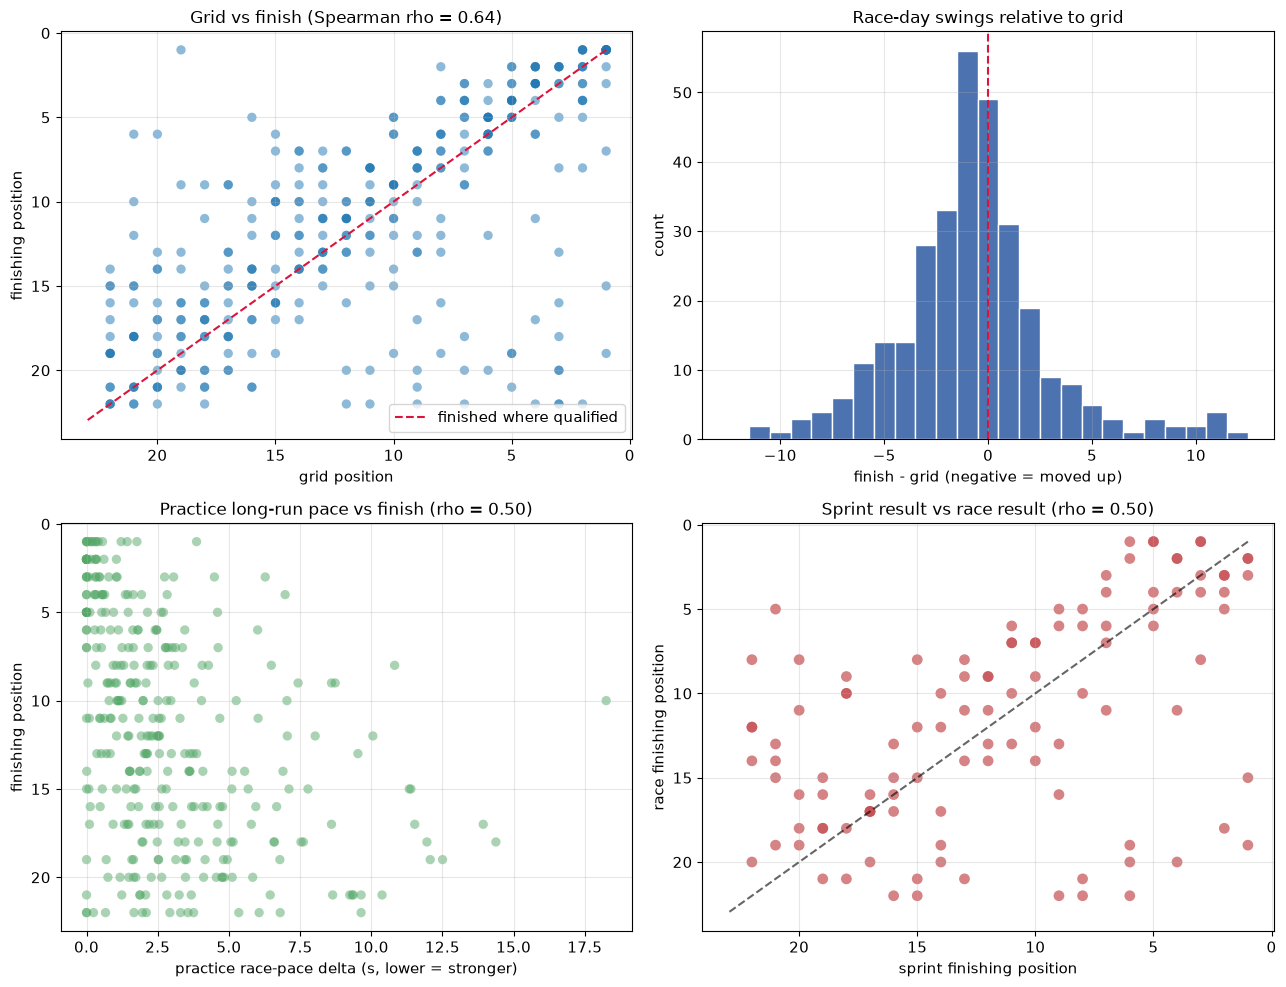

In [7]:
races = data[data["grid"].notna() & data["finish"].notna()]
spearman = races["grid"].corr(races["finish"], method="spearman")
pace = data[data["fp_race_pace_delta"].notna() & data["finish"].notna()]
pace_rho = pace["fp_race_pace_delta"].corr(pace["finish"], method="spearman")
sprint = data[data["sprint_finish"].notna() & data["finish"].notna()]
sprint_rho = sprint["sprint_finish"].corr(sprint["finish"], method="spearman")

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

axes[0, 0].scatter(races["grid"], races["finish"], s=45, alpha=0.5, edgecolor="none")
axes[0, 0].plot([1, 23], [1, 23], ls="--", c="crimson", label="finished where qualified")
axes[0, 0].invert_xaxis()
axes[0, 0].invert_yaxis()
axes[0, 0].set(xlabel="grid position", ylabel="finishing position",
               title=f"Grid vs finish (Spearman rho = {spearman:.2f})")
axes[0, 0].legend(loc="lower right")

axes[0, 1].hist(races["finish"] - races["grid"], bins=np.arange(-12.5, 13.5),
                color="#4c72b0", edgecolor="white")
axes[0, 1].axvline(0, c="crimson", ls="--")
axes[0, 1].set(xlabel="finish - grid (negative = moved up)", ylabel="count",
               title="Race-day swings relative to grid")

axes[1, 0].scatter(pace["fp_race_pace_delta"], pace["finish"], s=45, alpha=0.5,
                   edgecolor="none", color="#55a868")
axes[1, 0].invert_yaxis()
axes[1, 0].set(xlabel="practice race-pace delta (s, lower = stronger)",
               ylabel="finishing position",
               title=f"Practice long-run pace vs finish (rho = {pace_rho:.2f})")

axes[1, 1].scatter(sprint["sprint_finish"], sprint["finish"], s=60, alpha=0.7,
                   edgecolor="none", color="#c44e52")
axes[1, 1].plot([1, 23], [1, 23], ls="--", c="black", alpha=0.6)
axes[1, 1].invert_xaxis()
axes[1, 1].invert_yaxis()
axes[1, 1].set(xlabel="sprint finishing position", ylabel="race finishing position",
               title=f"Sprint result vs race result (rho = {sprint_rho:.2f})")

fig.tight_layout()
plt.show()

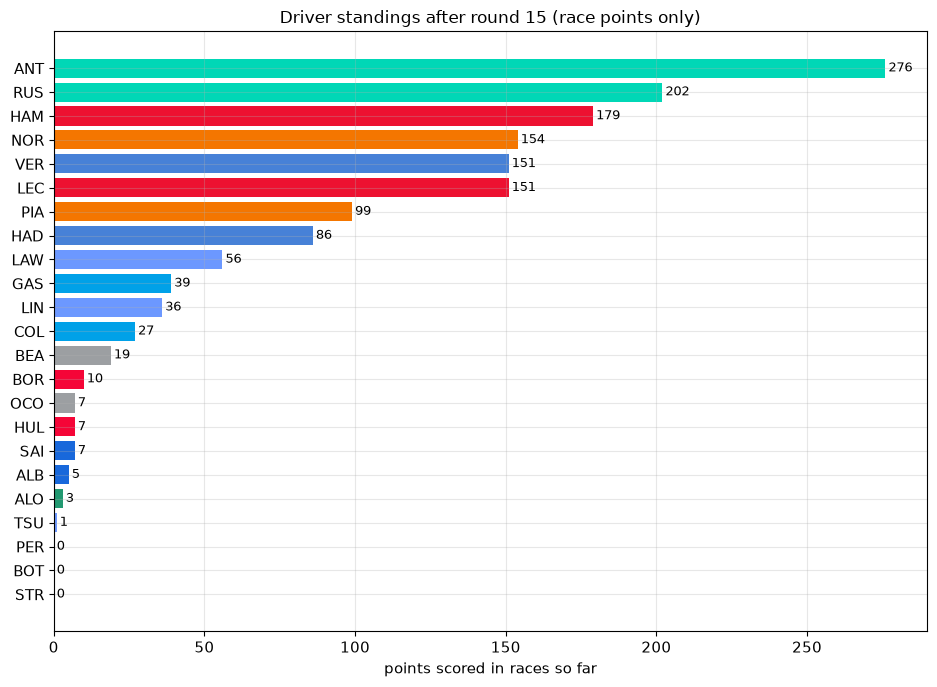

In [8]:
points = data.groupby("driver", as_index=False)["points"].sum()
points["team"] = points["driver"].map(data.sort_values("round").groupby("driver")["team"].last())
points = points.sort_values("points")
colors = [TEAM_COLORS.get(t, "#999999") for t in points["team"]]

fig, ax = plt.subplots(figsize=(9.5, 7))
ax.barh(points["driver"], points["points"], color=colors)
for y, v in enumerate(points["points"]):
    ax.text(v + 1, y, f"{v:.0f}", va="center", fontsize=9)
ax.set(xlabel="points scored in races so far",
       title=f"Driver standings after round {last_round} (race points only)")
fig.tight_layout()
plt.show()

## 4. Feature engineering

Every feature is computed **strictly from information available before the race**:

| feature | meaning |
|---|---|
| `grid` | official starting position |
| `quali_delta` | best qualifying time minus pole time (seconds) |
| `team_quali_delta` | `quali_delta` averaged over both cars of the driver's team (car pace) |
| `fp_race_pace_delta` | best rolling 5-lap average within a practice stint, relative to the fastest stint in that session - the "race pace" signal (best across FP1/FP2/FP3) |
| `fp_best_delta` | fastest clean practice lap minus that session's fastest lap (best across sessions) |
| `fp_laps` | clean practice laps completed across the weekend's sessions |
| `sprint_quali_pos` | sprint weekends only: starting position for the sprint (= sprint qualifying result) |
| `sprint_finish` | sprint weekends only: finishing position in the sprint race |
| `sprint_gain` | sprint weekends only: places gained in the sprint relative to the sprint grid |
| `driver_form_3` | driver's mean finishing position over the previous 3 races |
| `driver_form_season` | driver's mean finishing position over the whole season so far |
| `driver_last_finish` | driver's finishing position in the previous race |
| `team_form_3` / `team_form_season` | the same rolling/expanding means for the team's cars |
| `driver_points_before` / `team_points_before` | championship points scored before this race (grand prix only) |
| `team_id` | the constructor, as a categorical feature |

Sprint features exist only on sprint weekends (5 of the 15 completed rounds in 2026) and are `NaN` elsewhere; histogram gradient boosting consumes missing values natively, so no imputation is needed.

Leakage protection: the "before" features use `shift(1)` inside each driver's history, so a race is never described using its own result. Rookie races (no history yet) are `NaN` as well.

In [9]:
def build_features(data):
    df = data.copy()
    df["driver_number"] = df["driver_number"].astype(str)
    df = df.sort_values(["round", "driver_number"]).reset_index(drop=True)
    df["team_id"] = pd.factorize(df["team"])[0]
    df["team_race_mean"] = df.groupby(["round", "team"], sort=False)["finish"].transform("mean")
    df["team_race_points"] = df.groupby(["round", "team"], sort=False)["points"].transform("sum")
    df["team_quali_delta"] = df.groupby(["round", "team"], sort=False)["quali_delta"].transform("mean")
    by_driver = df.groupby("driver_number", sort=False)
    df["driver_last_finish"] = by_driver["finish"].transform(lambda s: s.shift(1))
    df["driver_form_3"] = by_driver["finish"].transform(lambda s: s.shift(1).rolling(3, min_periods=1).mean())
    df["driver_form_season"] = by_driver["finish"].transform(lambda s: s.shift(1).expanding(min_periods=1).mean())
    df["driver_points_before"] = by_driver["points"].transform(lambda s: s.cumsum().shift(1)).fillna(0.0)
    df["team_form_3"] = by_driver["team_race_mean"].transform(lambda s: s.shift(1).rolling(3, min_periods=1).mean())
    df["team_form_season"] = by_driver["team_race_mean"].transform(lambda s: s.shift(1).expanding(min_periods=1).mean())
    df["team_points_before"] = by_driver["team_race_points"].transform(lambda s: s.cumsum().shift(1)).fillna(0.0)
    return df

In [10]:
features = build_features(data)
print(features.shape)
features[["driver", "team", "grid", "quali_delta", "fp_race_pace_delta", "driver_form_3",
          "driver_form_season", "driver_points_before", "team_form_3", "finish"]].tail(22)

(330, 28)


,driver,team,grid,quali_delta,fp_race_pace_delta,driver_form_3,driver_form_season,driver_points_before,team_form_3,finish
308,NOR,McLaren,5.0,1.146,4.163467,2.666667,7.071429,154.0,4.500000,19.0
309,GAS,Alpine,7.0,1.521,4.584417,9.666667,10.071429,39.0,9.833333,18.0
310,PER,Cadillac,20.0,4.132,5.111333,17.666667,17.142857,0.0,18.000000,14.0
311,ANT,Mercedes,16.0,2.978,0.000000,1.333333,3.500000,266.0,2.333333,5.0
312,ALO,Aston Martin,21.0,4.067,0.000000,15.666667,16.642857,3.0,18.000000,21.0
313,LEC,Ferrari,2.0,0.837,1.636000,10.333333,7.142857,139.0,10.500000,4.0
314,STR,Aston Martin,22.0,4.811,5.347333,20.333333,18.571429,0.0,18.000000,22.0
315,ALB,Williams,12.0,2.475,5.116467,16.333333,16.428571,5.0,16.166667,20.0
316,HUL,Audi,18.0,3.394,0.831500,10.000000,13.857143,7.0,11.166667,11.0
317,VER,Red Bull Racing,8.0,1.180,0.000000,9.000000,8.428571,133.0,9.000000,2.0


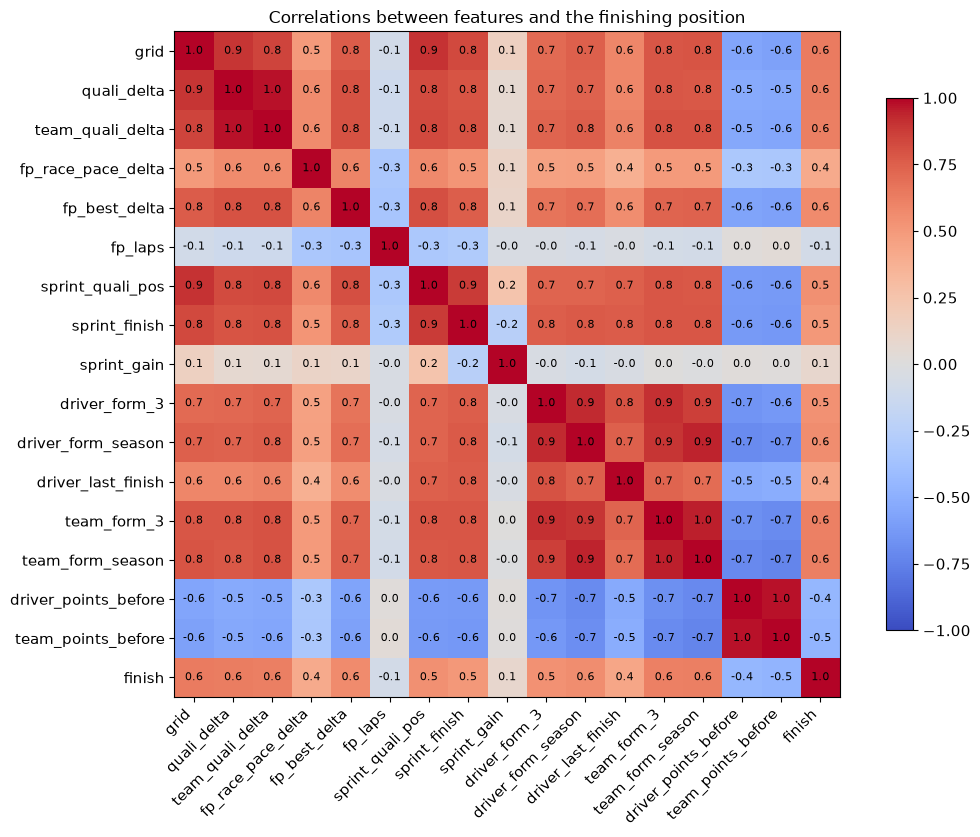

In [11]:
corr_cols = [f for f in FEATURES if f != "team_id"] + ["finish"]
corr = features[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8.5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)), corr_cols, rotation=45, ha="right")
ax.set_yticks(range(len(corr_cols)), corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.1f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, shrink=0.8)
ax.grid(False)
ax.set(title="Correlations between features and the finishing position")
fig.tight_layout()
plt.show()

## 5. The models

Two gradient-boosting models are trained on the same features with different targets:

- **gain model** - predicts *places gained/lost relative to the grid* (`finish - grid`); the predicted finishing score is `grid + prediction`. The grid anchor bakes in the strongest prior: if this model predicted "no change" everywhere it would exactly reproduce the starting order, so every move it makes is a claim of extra signal about racecraft, strategy and pace.
- **direct model** - predicts the **absolute finishing position** straight from the features, with no grid anchor in the target. It must learn the entire qualifying-to-race mapping itself, which gives it more freedom to disagree with the starting order when pace and form justify it - and more room to be wrong when the data is thin.

Both use `HistGradientBoostingRegressor` (native missing-value and categorical handling, well suited to a few hundred rows) with absolute-error loss so DNF outliers don't dominate the fit, shallow trees (`max_leaf_nodes=15`), `min_samples_leaf=20`, 150 boosting iterations and L2 regularisation - chosen to keep a 17-feature model honest on ~300 training rows.

Predictions become finishing orders by **ranking** the predicted scores; the rank is the predicted position. Which model deserves more trust is an empirical question, answered by the rolling backtest below.

In [12]:
def make_model():
    return HistGradientBoostingRegressor(
        loss="absolute_error",
        learning_rate=0.08,
        max_iter=150,
        max_leaf_nodes=15,
        min_samples_leaf=20,
        l2_regularization=1.0,
        categorical_features=[FEATURES.index("team_id")],
        random_state=42,
    )


def train_model(features, target_round, mode="gain"):
    train = features[
        (features["round"] < target_round)
        & features["finish"].notna()
        & features["grid"].notna()
    ]
    if train.empty:
        raise ValueError(f"no training data before round {target_round}")
    if mode == "gain":
        target = (train["finish"] - train["grid"]).to_numpy(dtype=float)
    else:
        target = train["finish"].to_numpy(dtype=float)
    model = make_model()
    model.fit(train[FEATURES].to_numpy(dtype=float), target)
    return model, train


def predict_round(model, features, target_round, mode="gain"):
    rows = features[(features["round"] == target_round) & features["grid"].notna()].copy()
    rows = rows.sort_values(["grid", "driver_number"])
    rows["model_output"] = model.predict(rows[FEATURES].to_numpy(dtype=float))
    if mode == "gain":
        rows["pred_finish"] = rows["grid"] + rows["model_output"]
    else:
        rows["pred_finish"] = rows["model_output"]
    rows["pred_pos"] = rows["pred_finish"].rank(method="first").astype(int)
    return rows.sort_values("pred_pos")


def rank_corr(a, b):
    ra = pd.Series(a).rank().to_numpy()
    rb = pd.Series(b).rank().to_numpy()
    if np.std(ra) == 0 or np.std(rb) == 0:
        return np.nan
    return float(np.corrcoef(ra, rb)[0, 1])

## 6. Rolling backtest - gain vs direct vs the grid

The season is simulated round by round with **no look-ahead**: for round *r*, both models are trained only on rounds `1..r-1`, predict round *r*, then move on. This mirrors exactly how the notebook would be used on a real race weekend.

Metrics per round, for **both models and the naive "grid = result" baseline**:

- **position MAE** - mean absolute error between predicted and actual finishing positions of all starters.
- **podium** - how many of the actual top-3 the predicted top-3 contains (0-3).
- **winner** - whether the predicted P1 is the actual winner.
- **rank corr** - Spearman correlation between predicted and actual finishing orders.

In [13]:
def run_backtest(features, min_train_rounds=MIN_TRAIN_ROUNDS):
    rounds = sorted(features["round"].unique())
    records = []
    for r in rounds:
        if sum(1 for x in rounds if x < r) < min_train_rounds:
            continue
        try:
            gain_model, _ = train_model(features, r, "gain")
            direct_model, _ = train_model(features, r, "direct")
        except ValueError:
            continue
        gain = predict_round(gain_model, features, r, "gain")
        direct = predict_round(direct_model, features, r, "direct")
        gain_scored = gain[gain["finish"].notna()]
        direct_scored = direct[direct["finish"].notna()]
        winner_row = features.loc[(features["round"] == r) & (features["finish"] == 1), "driver"]
        if gain_scored.empty or winner_row.empty:
            continue
        winner = winner_row.iloc[0]
        actual_top3 = set(features.loc[(features["round"] == r) & (features["finish"] <= 3), "driver"])
        records.append({
            "round": r,
            "event": str(features.loc[features["round"] == r, "event"].iloc[0]),
            "gain_mae": float((gain_scored["pred_pos"] - gain_scored["finish"]).abs().mean()),
            "direct_mae": float((direct_scored["pred_pos"] - direct_scored["finish"]).abs().mean()),
            "grid_mae": float((gain_scored["grid"].rank(method="first") - gain_scored["finish"]).abs().mean()),
            "gain_podium": len(actual_top3 & set(gain.head(3)["driver"])),
            "direct_podium": len(actual_top3 & set(direct.head(3)["driver"])),
            "grid_podium": len(actual_top3 & set(gain_scored.nsmallest(3, "grid")["driver"])),
            "gain_winner": 1 if gain.iloc[0]["driver"] == winner else 0,
            "direct_winner": 1 if direct.iloc[0]["driver"] == winner else 0,
            "grid_winner": 1 if gain_scored.nsmallest(1, "grid")["driver"].iloc[0] == winner else 0,
            "gain_corr": rank_corr(gain_scored["pred_pos"], gain_scored["finish"]),
            "direct_corr": rank_corr(direct_scored["pred_pos"], direct_scored["finish"]),
        })
    return pd.DataFrame(records)

In [14]:
bt = run_backtest(features)
display(bt.round(2))
print()
n = len(bt)
print(f"{'':<28} {'gain':>7} {'direct':>8} {'grid-only':>9}")
print(f"{'position MAE':<28} {bt['gain_mae'].mean():>7.2f} {bt['direct_mae'].mean():>8.2f} {bt['grid_mae'].mean():>9.2f}")
print(f"{'podium hit rate':<28} {bt['gain_podium'].sum() / (3 * n):>6.0%} {bt['direct_podium'].sum() / (3 * n):>7.0%} {bt['grid_podium'].sum() / (3 * n):>8.0%}")
print(f"{'winner hit rate':<28} {bt['gain_winner'].mean():>6.0%} {bt['direct_winner'].mean():>7.0%} {bt['grid_winner'].mean():>8.0%}")
print(f"{'rank correlation':<28} {bt['gain_corr'].mean():>7.2f} {bt['direct_corr'].mean():>8.2f}")

,round,event,gain_mae,direct_mae,grid_mae,gain_podium,direct_podium,grid_podium,gain_winner,direct_winner,grid_winner,gain_corr,direct_corr
0,6,Monaco Grand Prix,5.18,5.36,5.09,2,2,2,1,1,1,0.38,0.36
1,7,Barcelona Grand Prix,3.27,4.00,3.09,2,2,2,1,0,0,0.74,0.67
2,8,Austrian Grand Prix,2.18,2.82,1.82,1,1,1,0,0,1,0.92,0.88
3,9,British Grand Prix,4.45,4.73,4.36,2,3,2,0,0,0,0.59,0.55
4,10,Belgian Grand Prix,3.45,2.64,2.91,3,2,2,1,1,1,0.62,0.78
5,11,Hungarian Grand Prix,2.36,3.00,2.45,2,1,1,1,0,1,0.80,0.80
6,12,Dutch Grand Prix,2.82,3.45,2.82,2,2,3,1,0,1,0.74,0.69
7,13,Italian Grand Prix,3.82,2.82,3.82,1,2,1,0,0,0,0.47,0.67
8,14,Spanish Grand Prix,2.27,2.36,2.18,3,2,3,0,0,0,0.80,0.81
9,15,Azerbaijan Grand Prix,5.18,4.91,4.91,1,2,1,1,1,1,0.43,0.51



                                gain   direct grid-only
position MAE                    3.50     3.61      3.35
podium hit rate                 63%     63%      60%
winner hit rate                 60%     30%      60%
rank correlation                0.65     0.67


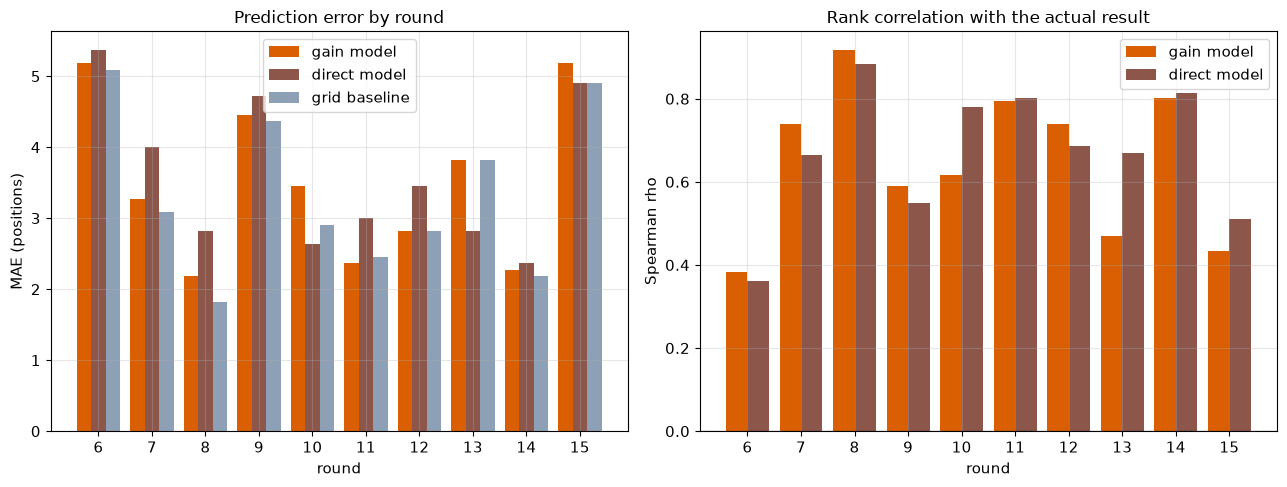

In [15]:
x = np.arange(len(bt))
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(x - 0.27, bt["gain_mae"], width=0.27, label="gain model", color="#d95f02")
axes[0].bar(x, bt["direct_mae"], width=0.27, label="direct model", color="#8c564b")
axes[0].bar(x + 0.27, bt["grid_mae"], width=0.27, label="grid baseline", color="#8ea0b5")
axes[0].set_xticks(x, bt["round"])
axes[0].set(xlabel="round", ylabel="MAE (positions)", title="Prediction error by round")
axes[0].legend()

axes[1].bar(x - 0.2, bt["gain_corr"], width=0.4, label="gain model", color="#d95f02")
axes[1].bar(x + 0.2, bt["direct_corr"], width=0.4, label="direct model", color="#8c564b")
axes[1].axhline(0, c="black", lw=0.8)
axes[1].set_xticks(x, bt["round"])
axes[1].set(xlabel="round", ylabel="Spearman rho",
            title="Rank correlation with the actual result")
axes[1].legend()
fig.tight_layout()
plt.show()

## 7. Predicting a race

The notebook picks a target race automatically:

- If the **next round's qualifying** has already happened, that race is predicted for real (grid estimated from the qualifying classification; grid penalties not applied).
- Otherwise it demonstrates on the **last completed race**, so the prediction can be scored against the actual result.

Set `TARGET_ROUND` below to force a specific round instead.

In the result table, `gain` and `direct` are the predicted positions from the two models, `grid` is the starting slot, and `gain_err` is the gain model's position error against the actual result (negative = the model underrated the driver).

In [16]:
TARGET_ROUND = None

now = utc_now()
completed_rounds = set(data["round"])
upcoming_rows = [row for _, row in schedule.iterrows()
                 if session_utc(row, "Race") is not None and session_utc(row, "Race") > now]

if TARGET_ROUND is not None:
    target_round = TARGET_ROUND
    row = schedule[schedule["RoundNumber"] == target_round].iloc[0]
    event_name = str(row["EventName"])
    race_utc = session_utc(row, "Race")
    quali_utc = session_utc(row, "Qualifying")
    if race_utc is not None and race_utc < now:
        if target_round in completed_rounds:
            mode = "post"
        else:
            raise SystemExit(f"round {target_round} happened recently but is not in the cache yet, retry in a few hours")
    elif quali_utc is not None and quali_utc < now:
        mode = "pre"
    else:
        raise SystemExit(f"round {target_round}: qualifying has not happened yet")
elif upcoming_rows and session_utc(upcoming_rows[0], "Qualifying") is not None and session_utc(upcoming_rows[0], "Qualifying") < now:
    target_round = int(upcoming_rows[0]["RoundNumber"])
    event_name = str(upcoming_rows[0]["EventName"])
    mode = "pre"
else:
    if upcoming_rows:
        print(f"qualifying for the next round ({upcoming_rows[0]['EventName']}) has not happened yet,")
        print("so the notebook demonstrates on the last completed race instead")
    else:
        print(f"the {SEASON} season is over, demonstrating on the final round")
    target_round = int(data["round"].max())
    event_name = str(data.loc[data["round"] == target_round, "event"].iloc[0])
    mode = "post"

print(f"target: round {target_round} - {event_name} - "
      f"{'real prediction (race has not happened)' if mode == 'pre' else 'completed race, scored vs the actual result'}")

qualifying for the next round (Bahrain Grand Prix) has not happened yet,
so the notebook demonstrates on the last completed race instead
target: round 15 - Azerbaijan Grand Prix - completed race, scored vs the actual result


In [17]:
if mode == "pre":
    upcoming = load_upcoming_round(SEASON, target_round, event_name)
    model_data = pd.concat([data[data["round"] != target_round], upcoming], ignore_index=True)
else:
    model_data = data

features_final = build_features(model_data)
gain_model, train_set = train_model(features_final, target_round, "gain")
direct_model, _ = train_model(features_final, target_round, "direct")
gain = predict_round(gain_model, features_final, target_round, "gain")
direct = predict_round(direct_model, features_final, target_round, "direct")

result = pd.DataFrame({
    "gain": gain["pred_pos"].to_numpy(),
    "direct": gain["driver"].map(direct.set_index("driver")["pred_pos"]).to_numpy(),
    "driver": gain["driver"].to_numpy(),
    "team": gain["team"].to_numpy(),
    "grid": gain["grid"].astype(int).to_numpy(),
})
if mode == "post":
    result["actual"] = gain["finish"].astype("Int64").to_numpy()
    result["gain_err"] = (gain["pred_pos"] - gain["finish"]).round().astype("Int64").to_numpy()

print(f"predicted podium (gain model)   : {' '.join(result.head(3)['driver'])}")
print(f"predicted podium (direct model) : {' '.join(result.sort_values('direct').head(3)['driver'])}")
if mode == "post":
    print(f"actual podium                   : {' '.join(gain.nsmallest(3, 'finish')['driver'])}")
else:
    print(f"predicted winner (gain model)   : {result.iloc[0]['driver']}")
    print(f"predicted winner (direct model) : {result.sort_values('direct').iloc[0]['driver']}")
result

predicted podium (gain model)   : RUS PIA LEC
predicted podium (direct model) : RUS HAD PIA
actual podium                   : RUS VER HAD


,gain,direct,driver,team,grid,actual,gain_err
0,1,1,RUS,Mercedes,1,1,0
1,2,3,PIA,McLaren,3,13,-11
2,3,4,LEC,Ferrari,2,4,-1
3,4,2,HAD,Red Bull Racing,4,3,1
4,5,6,GAS,Alpine,7,18,-13
5,6,7,NOR,McLaren,5,19,-13
6,7,8,HAM,Ferrari,6,6,1
7,8,10,COL,Alpine,9,17,-9
8,9,5,VER,Red Bull Racing,8,2,7
9,10,13,BEA,Haas F1 Team,10,9,1


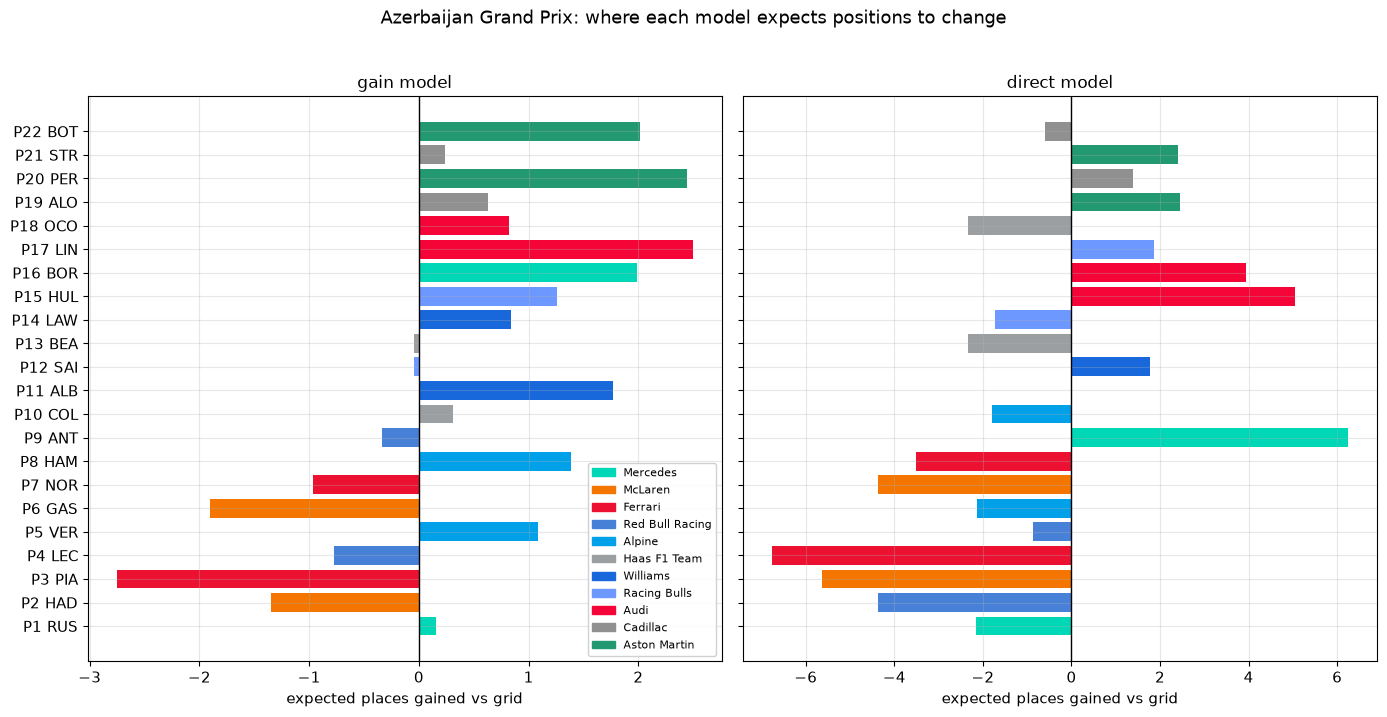

In [18]:
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharey=True)
for ax, pred, name in ((axes[0], gain, "gain model"), (axes[1], direct, "direct model")):
    ordered = pred.sort_values("pred_pos")
    y = np.arange(len(ordered))
    colors = [TEAM_COLORS.get(t, "#999999") for t in ordered["team"]]
    ax.barh(y, ordered["grid"] - ordered["pred_finish"], color=colors)
    ax.set_yticks(y, [f"P{p} {d}" for p, d in zip(ordered["pred_pos"], ordered["driver"])])
    ax.invert_yaxis()
    ax.axvline(0, c="black", lw=1)
    ax.set(xlabel="expected places gained vs grid", title=name)
handles = [Patch(color=TEAM_COLORS.get(t, "#999999"), label=t) for t in gain["team"].unique()]
axes[0].legend(handles=handles, loc="lower right", fontsize=8, framealpha=0.9)
fig.suptitle(f"{event_name}: where each model expects positions to change", y=1.02)
fig.tight_layout()
plt.show()

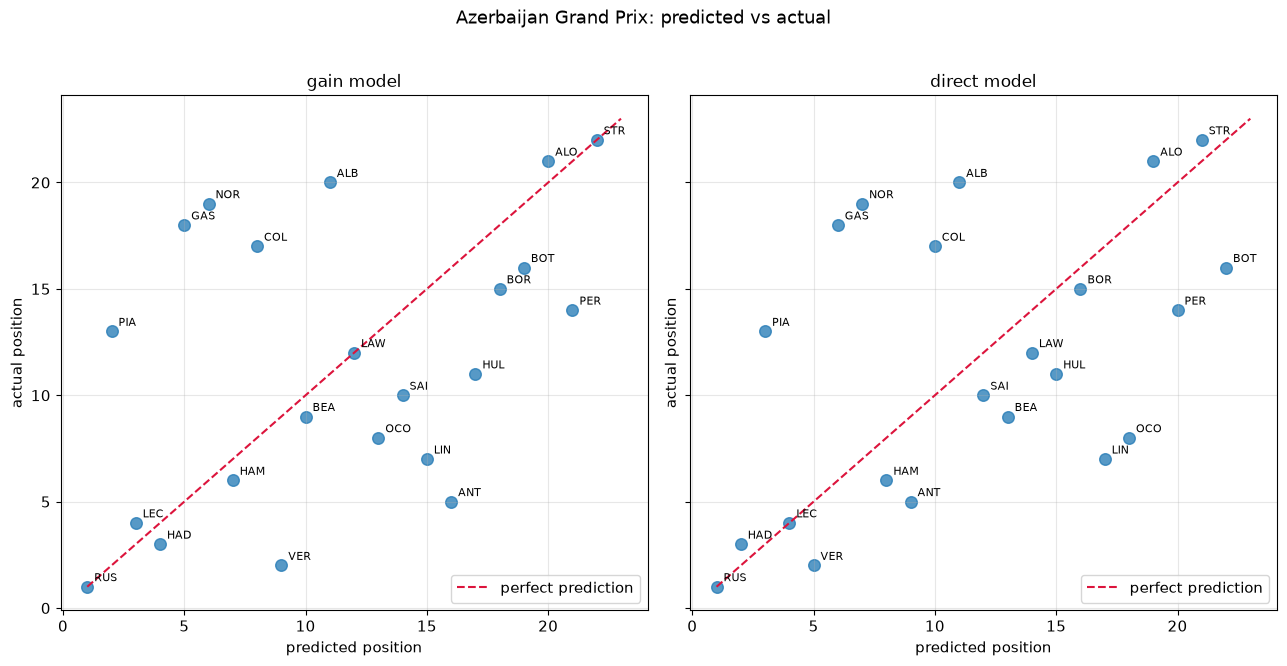

In [19]:
if mode == "post":
    fig, axes = plt.subplots(1, 2, figsize=(13, 6.5), sharex=True, sharey=True)
    for ax, pred, name in ((axes[0], gain, "gain model"), (axes[1], direct, "direct model")):
        ax.scatter(pred["pred_pos"], pred["finish"], s=70, alpha=0.75)
        for _, row in pred.iterrows():
            ax.annotate(row["driver"], (row["pred_pos"], row["finish"]),
                        xytext=(5, 4), textcoords="offset points", fontsize=8)
        ax.plot([1, 23], [1, 23], ls="--", c="crimson", label="perfect prediction")
        ax.invert_xaxis()
        ax.invert_yaxis()
        ax.set(xlabel="predicted position", ylabel="actual position", title=name)
        ax.legend(loc="lower right")
    fig.suptitle(f"{event_name}: predicted vs actual", y=1.02)
    fig.tight_layout()
    plt.show()

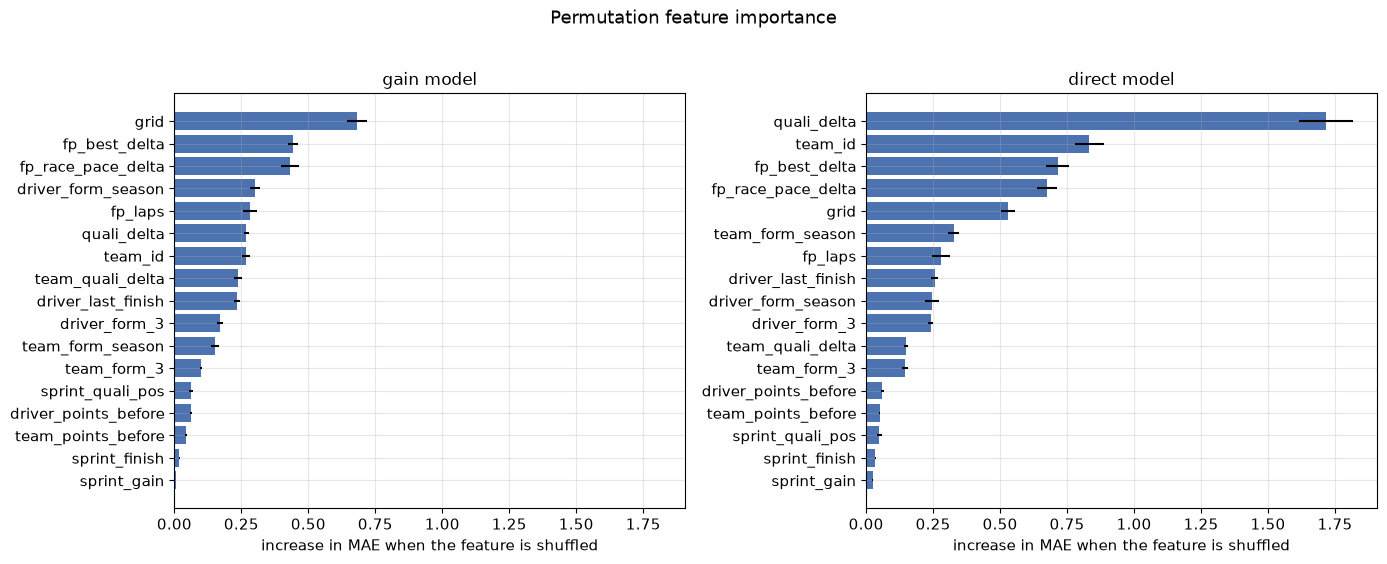

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharex=True)
for ax, model, name in ((axes[0], gain_model, "gain model"), (axes[1], direct_model, "direct model")):
    if name == "gain model":
        target_y = (train_set["finish"] - train_set["grid"]).to_numpy(dtype=float)
    else:
        target_y = train_set["finish"].to_numpy(dtype=float)
    imp = permutation_importance(
        model,
        train_set[FEATURES].to_numpy(dtype=float),
        target_y,
        scoring="neg_mean_absolute_error",
        n_repeats=5,
        random_state=42,
    )
    order = np.argsort(imp.importances_mean)
    ax.barh(np.array(FEATURES)[order], imp.importances_mean[order],
            xerr=imp.importances_std[order], color="#4c72b0")
    ax.set(xlabel="increase in MAE when the feature is shuffled", title=name)
fig.suptitle("Permutation feature importance", y=1.02)
fig.tight_layout()
plt.show()

## 8. Takeaways & next steps

- The grid alone is a strong predictor; the ML models compete with the naive "grid = result" baseline on outright MAE while beating it on podium and winner hits. The backtest shows the comparison round by round.
- Two targets, two characters: the **gain model** anchors on the grid and predicts who over/under-performs it, while the **direct model** predicts the absolute finishing position from pace and form alone. The backtest above shows which one earned more trust this season - and where they disagree (see the prediction table).
- Practice long-run pace is the strongest feature after the grid itself, and on sprint weekends the sprint result gives the models a real race from the same weekend - the freshest form signal available.
- Every feature is pre-race information, so this is exactly the pipeline you could run on a Saturday evening after qualifying: re-run the notebook and get a full predicted order for Sunday.
- Chaotic races (safety cars, first-lap collisions, weather) put a hard limit on achievable accuracy - retirements alone inject several positions of unavoidable noise.

Ideas to extend:

- **Richer lap data**: tyre-compound and stint-length adjustments to practice pace, sector times.
- **Weather**: rain probability strongly moderates the grid -> finish mapping.
- **Retirement model**: a separate classifier for P(finish), pushing DNF-prone cars back.
- **More seasons**: multi-season training with track-history features (a driver's past results at the same circuit).
- **Uncertainty**: quantile regression for prediction intervals instead of point predictions.
- **Ensemble**: blend the gain and direct models' predicted orders into one consensus ranking.